# AutoEIT — transcribed-v2 Hit/Miss Analysis
Each recording in `data/transcribed/v2/` should ideally contain exactly 30 re-transcribed items
(the expected size of the Spanish narrative section between the last English and last Spanish
target-sentence items). This notebook:
1. Classifies every recording as `"hit"` (exactly 30 items) or `"miss"` (anything else), and
   persists this as `hit_miss` in each recording's `data/transcribed/v2/{version}/{recording}/summary.json`.
2. Plots the hit/miss distribution, combined and per version.
3. For misses only, looks up the recording's original `category` (`good` / `long anomaly`) from
   `data/transcribed/v1/{version}/{recording}/summary.json` and plots that breakdown.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Config

In [2]:
TRANSCRIBED_ROOT = Path("../../data/transcribed/v1")
TRANSCRIBED_V2_ROOT = Path("../../data/transcribed/v2")
VERSIONS = ["version_a", "version_b"]

HIT_ITEM_COUNT = 30  # a recording is a "hit" iff it has exactly this many re-transcribed items


def classify_hit_miss(item_count: int) -> str:
    return "hit" if item_count == HIT_ITEM_COUNT else "miss"

## Load transcribed-v2 summaries, classify hit/miss, persist back to summary.json

In [3]:
rows = []

for version in VERSIONS:
    version_dir = TRANSCRIBED_V2_ROOT / version
    for summary_path in sorted(version_dir.glob("*/summary.json")):
        with open(summary_path, encoding="utf-8") as f:
            s = json.load(f)

        hit_miss = classify_hit_miss(s["item_count"])
        s["hit_miss"] = hit_miss
        with open(summary_path, "w", encoding="utf-8") as f:
            json.dump(s, f, ensure_ascii=False, indent=2)

        rows.append({
            "recording": s["recording"],
            "version": s["version"],
            "item_count": s["item_count"],
            "hit_miss": hit_miss,
        })

df = pd.DataFrame(rows)
print(f"{len(df)} recordings updated with hit_miss")
print(df["hit_miss"].value_counts())

187 recordings updated with hit_miss
hit_miss
miss    103
hit      84
Name: count, dtype: int64


## 1. Hit/miss distribution — combined and per version

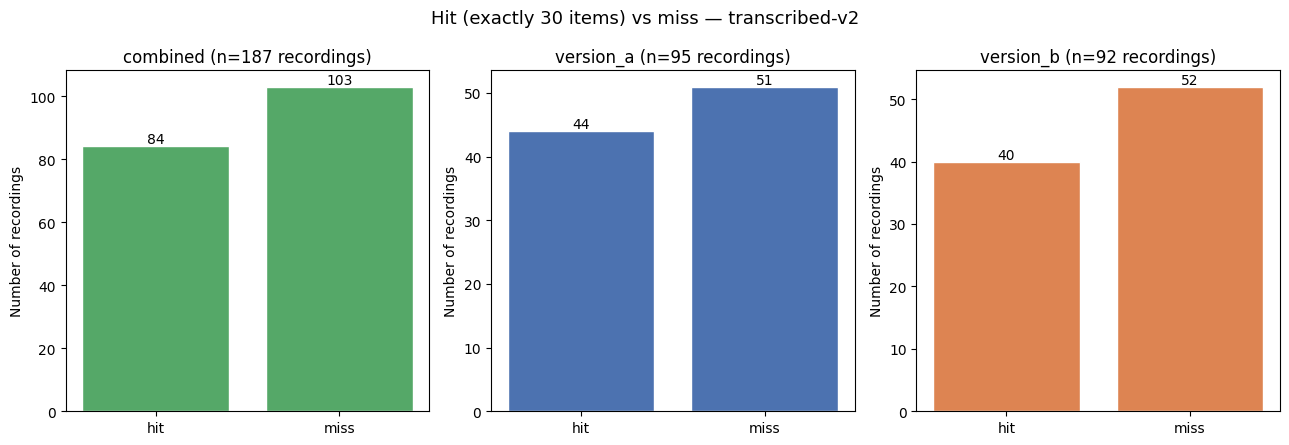

In [4]:
colors = {"version_a": "#4C72B0", "version_b": "#DD8452"}
hit_miss_order = ["hit", "miss"]

panels = [
    ("combined", df, "#55A868"),
    ("version_a", df[df["version"] == "version_a"], colors["version_a"]),
    ("version_b", df[df["version"] == "version_b"], colors["version_b"]),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=False)
for ax, (label, sub, color) in zip(axes, panels):
    counts = sub["hit_miss"].value_counts().reindex(hit_miss_order, fill_value=0)
    ax.bar(counts.index, counts.values, color=color, edgecolor="white")
    ax.set_title(f"{label} (n={len(sub)} recordings)", fontsize=12)
    ax.set_ylabel("Number of recordings")
    for i, v in enumerate(counts.values):
        ax.text(i, v, str(v), ha="center", va="bottom")

fig.suptitle("Hit (exactly 30 items) vs miss — transcribed-v2", fontsize=13)
fig.tight_layout()
plt.savefig("../plots/transcribed_v2_hit_miss_distribution.png", dpi=150)
plt.show()

## 2. Misses — breakdown by original category
Looks up each miss recording's original `category` (`good` / `long anomaly`) from
`data/transcribed/v1/{version}/{recording}/summary.json`.

In [5]:
def load_original_category(recording: str, version: str) -> str:
    summary_path = TRANSCRIBED_ROOT / version / recording / "summary.json"
    with open(summary_path, encoding="utf-8") as f:
        return json.load(f)["category"]


misses = df[df["hit_miss"] == "miss"].copy()
misses["original_category"] = misses.apply(
    lambda r: load_original_category(r["recording"], r["version"]), axis=1
)

print(f"{len(misses)} miss recording(s):")
display(
    misses[["recording", "version", "item_count", "original_category"]]
    .sort_values(["version", "item_count"])
    .reset_index(drop=True)
)

103 miss recording(s):


,recording,version,item_count,original_category
0,038021_EIT-1A,version_a,25,good
1,038.104_EITv-1A,version_a,29,good
2,038010_EIT-2A,version_a,29,good
3,038012_EIT-2A,version_a,29,long anomaly
4,038019_EIT-1A,version_a,29,good
...,...,...,...,...
98,038028_EITv-1B,version_b,55,long anomaly
99,038.087_EIT1_vB,version_b,56,long anomaly
100,038.087_EIT1_vB (1),version_b,56,long anomaly
101,038.084_EIT2_vB,version_b,58,long anomaly


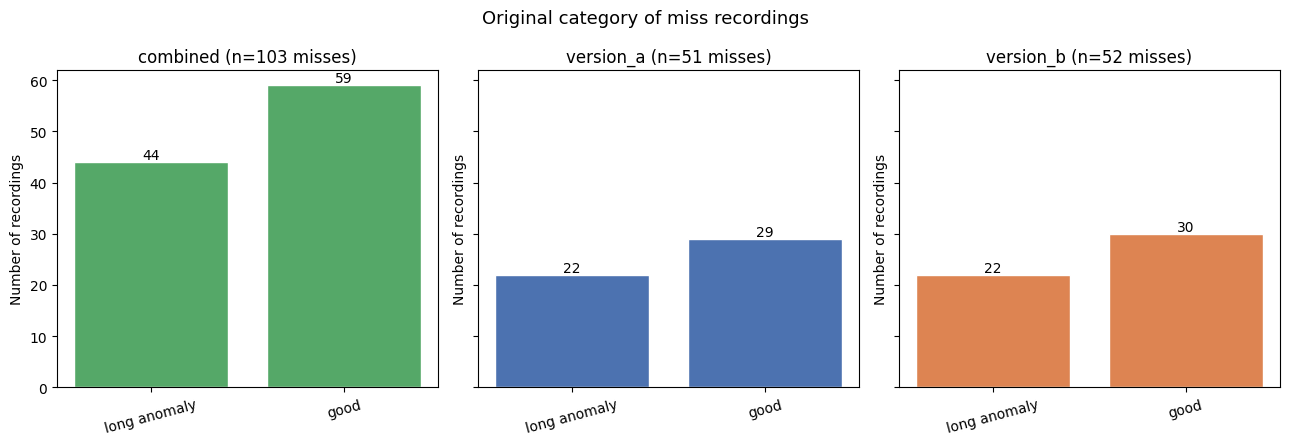

In [6]:
category_order = ["long anomaly", "good"]

panels = [
    ("combined", misses, "#55A868"),
    ("version_a", misses[misses["version"] == "version_a"], colors["version_a"]),
    ("version_b", misses[misses["version"] == "version_b"], colors["version_b"]),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)
for ax, (label, sub, color) in zip(axes, panels):
    counts = sub["original_category"].value_counts().reindex(category_order, fill_value=0)
    ax.bar(counts.index, counts.values, color=color, edgecolor="white")
    ax.set_title(f"{label} (n={len(sub)} misses)", fontsize=12)
    ax.set_ylabel("Number of recordings")
    ax.tick_params(axis="x", rotation=15)
    for i, v in enumerate(counts.values):
        ax.text(i, v, str(v), ha="center", va="bottom")

fig.suptitle("Original category of miss recordings", fontsize=13)
fig.tight_layout()
plt.savefig("../plots/transcribed_v2_miss_original_category.png", dpi=150)
plt.show()